### Measuring the Amplitude Spectrum for the Photonis MCPPMT's Green & Aqua using the Oscilloscope

In [2]:
import pandas as pd
import numpy as np
import scipy as sp
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import csv
import pyarrow as pa 
import RS_RTxReadBin as rb  
from RS_RTxReadBin.RTxReadBin import RTxReadBin  
import os 
from scipy.optimize import curve_fit
from pathlib import Path

In [3]:
import functions_singledata as my_fcts
import importlib

In [189]:
importlib.reload(my_fcts)

<module 'functions_singledata' from '/Users/laloscola/Library/Mobile Documents/com~apple~CloudDocs/Arbeit/Max-Planck/magic coding new /code_for_MCPPMT_Camera/functions_singledata.py'>

## Calculating Amplitude Spectrum for Green and Aqua

In [37]:
df = my_fcts.converter_binary_to_df('/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_000.Wfm.bin')

Found multichannel File, with channels: 1, 2, 3. Using these!


Resolution -> 1e-12
RecordLength -> 20000.0
Number of Acquisitions: 5000
Timestamps recorded: Yes
Number of channels given: 3


In [ ]:
my_fcts.main_ratio_and_plots(df, min_thresh=-0.015, filter_channels=('Ch_3',) , show_channels={'Ch_2' : 2, 'Ch_3' : 3})

Fixed window:
- for channel 3: (0.07e-8, 0.25e-8)
- for channel 2: (0.17e-8, 0.35e-8)

$\rightarrow$ Delay of 1ns between the two signals

## Calculation of Amplitudes

In [59]:
path_sig = Path('/Users/laloscola/ExternalDrive/photonis_green&aqua/')
files_sig = list(path_sig.glob('Run_*.Wfm.bin'))
count_sig = len(files_sig)
print(f'There are {count_sig} signal files')

There are 10 signal files


In [60]:
dx = 0.5e-12 # max resolution was 1e-12 (area can still have non-integer values) --- adapt such that selecting the number of bins autosets dx
bin_edges_jitter = np.arange(-15e-9, 15e-9 + dx, dx) # this would give 10000 bins
bin_edges_ampl = np.arange(0e-10, 2e-10 +dx, dx)

In [67]:
all_ampl_new = []
for file_path_sig in sorted(files_sig): # looping over first 3 files now
    print(file_path_sig)
    df = my_fcts.converter_binary_to_df(file_path_sig, show_info=False)
    # main_ratio_and_plots(df, min_thresh=-0.01, show_only_camera=False)
    values_ampl = my_fcts.main_amplitude_spectrum(df, channel='Ch_3', fixed_window=True, show_plots=False,integration_range=(0.07e-8, 0.25e-8))
    all_ampl_new.append(np.asarray(values_ampl))

all_ampl_fixed_window = np.concatenate(all_ampl_new)

/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_000.Wfm.bin


Found multichannel File, with channels: 1, 2, 3. Using these!
Found multichannel File, with channels: 1, 2, 3. Using these!


The mean area is: 5.464156675527499e-12 Vs
/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_002.Wfm.bin


Found multichannel File, with channels: 1, 2, 3. Using these!


The mean area is: 4.952153838534491e-12 Vs
/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_004.Wfm.bin


...

The mean area is: 5.053441147547058e-12 Vs
/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_014.Wfm.bin


Found multichannel File, with channels: 1, 2, 3. Using these!


The mean area is: 5.248010790044291e-12 Vs
/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_016.Wfm.bin


Found multichannel File, with channels: 1, 2, 3. Using these!


The mean area is: 5.23220924375084e-12 Vs
/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_018.Wfm.bin
The mean area is: 4.8897920297945326e-12 Vs


In [68]:
# np.save('all_ampl_ch3_aqua.npy', all_ampl_fixed_window)

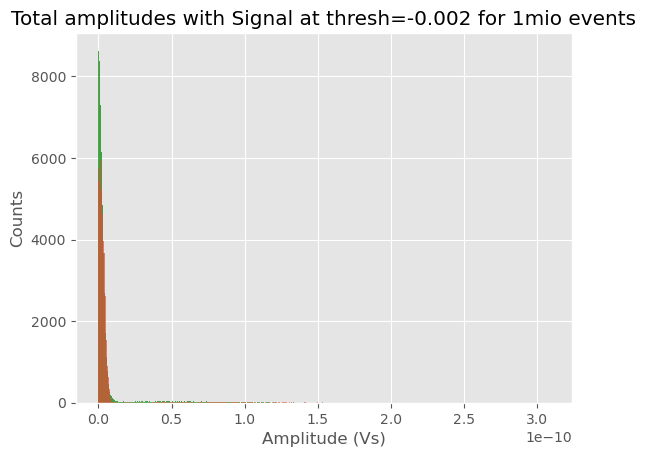

In [69]:
bin_left = bin_edges_ampl[:-1]
bin_width = np.diff(bin_edges_ampl)

all_green = np.load('all_ampl_ch2_green.npy')
all_aqua = np.load('all_ampl_ch3_aqua.npy')

plt.figure()
plt.style.use('ggplot')

plt.hist(all_green, bins='auto', color='green', alpha=0.7)
plt.hist(all_aqua, bins='auto', alpha=0.7)
plt.xlabel(f"Amplitude (Vs)")
plt.ylabel("Counts")
plt.title("Total amplitudes with Signal at thresh=-0.002 for 1mio events")
plt.show()

## Now Plots of Amplitudes

In [112]:
dx = 0.3e-12 # max resolution was 1e-12 (area can still have non-integer values) --- adapt such that selecting the number of bins autosets dx
bin_edges_jitter = np.arange(-15e-9, 15e-9 + dx, dx) # this would give 10000 bins
bin_edges_ampl = np.arange(0e-10, 2e-11 +dx, dx)

4053 3292


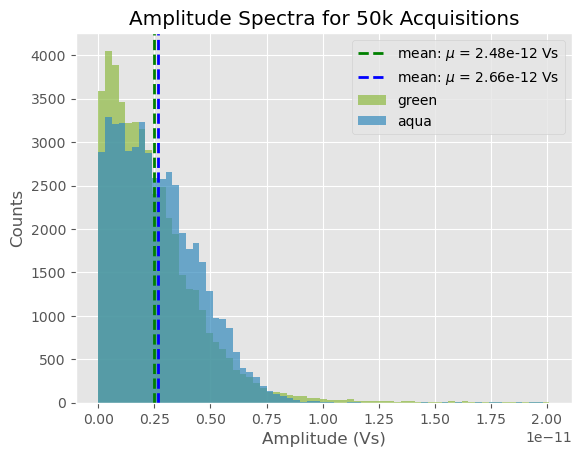

In [129]:
all_ampl_green = np.load('all_ampl_ch2_green.npy')
all_ampl_aqua = np.load('all_ampl_ch3_aqua.npy')

bin_left = bin_edges_ampl[:-1]
bin_width = np.diff(bin_edges_ampl)

G, edges_g = np.histogram(all_ampl_green, bins=bin_edges_ampl) # looses the 1e-11
B, edges_g = np.histogram(all_ampl_aqua, bins=bin_edges_ampl)

#Ns = max(all_ampl_green)
#Nb = max(all_ampl_aqua)
Ng = max(np.histogram(all_ampl_green, bins=bin_edges_ampl)[0]) # needed for normalisation -> S - N_S/N_B * B
Nb = max(np.histogram(all_ampl_aqua, bins=bin_edges_ampl)[0])
print(Ng, Nb)

centers_g = 0.5 * (edges_g[:-1] + edges_g[1:])
mu_g = np.average(centers_g, weights=G)

centers_b = 0.5 * (edges_b[:-1] + edges_b[1:])
mu_b = np.average(centers_b, weights=B)

plt.figure()
plt.style.use('ggplot')
#plt.stairs(S/Ns, edges_s, alpha=1, label='greennal')
#plt.stairs(B/Nb, edges_b, alpha=1, label='Background')
plt.bar(bin_left, G, width=bin_width, align='edge', color='C5', alpha=0.7, label='green')
plt.bar(bin_left, B, width=bin_width, align='edge', color='C1', alpha=0.7, label='aqua')

plt.axvline(mu_g, color="green", linestyle="--", linewidth=2,  label=fr'mean: $\mu$ = {mu_g:.3g} Vs')   
plt.axvline(mu_b, color="blue", linestyle="--", linewidth=2,  label=fr'mean: $\mu$ = {mu_b:.3g} Vs')   

#plt.yscale('log')                 # <-- add this (log y-axis) [web:2]


plt.xlabel(f"Amplitude (Vs)")
plt.ylabel("Counts")
plt.legend()
plt.title("Amplitude Spectra for 50k Acquisitions")
plt.savefig("amplitude_aqua_green.png", dpi=300, bbox_inches="tight")

plt.show()

## Jitter Calculation

In [133]:
path_sig = Path('/Users/laloscola/ExternalDrive/photonis_green&aqua/')
files_sig = list(path_sig.glob('Run_*.Wfm.bin'))
count_sig = len(files_sig)
print(f'There are {count_sig} signal files')

There are 10 signal files


In [ ]:
my_fcts.main_ratio_and_plots(df, min_thresh=-0.018, filter_channels=('Ch_2',) , show_channels={'Ch_2' : 2, 'Ch_3' : 3})

min_thresh for clean peaks:
- Channel 2:  -0.018 -> 8.5% ratio
- Channel 3:  -0.023 -> 2.4% ratio

In [191]:
all_deltas =  []
for file_path_sig in sorted(files_sig):
    print(file_path_sig)
    df = my_fcts.converter_binary_to_df(file_path_sig, show_info=False)

    deltas, mean_offset, jitter = my_fcts.main_jitter_plot_and_fwhm(df, min_thresh=-0.023, bins_fit=5000, bins=5000 ,show_plots=False, ch_ref='Ch_1', ch_test='Ch_3')
    print(len(deltas))
    all_deltas.append(np.asarray(deltas))
all_deltas =  np.concatenate(all_deltas)

Found multichannel File, with channels: 1, 2, 3. Using these!


/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_000.Wfm.bin
177
/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_002.Wfm.bin


Found multichannel File, with channels: 1, 2, 3. Using these!
Found multichannel File, with channels: 1, 2, 3. Using these!


134
/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_004.Wfm.bin


Found multichannel File, with channels: 1, 2, 3. Using these!


...

149
/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_014.Wfm.bin


Found multichannel File, with channels: 1, 2, 3. Using these!


155
/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_016.Wfm.bin


Found multichannel File, with channels: 1, 2, 3. Using these!


160
/Users/laloscola/ExternalDrive/photonis_green&aqua/Run_018.Wfm.bin
128


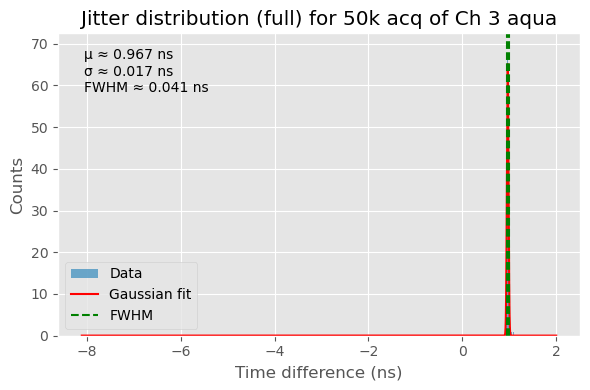

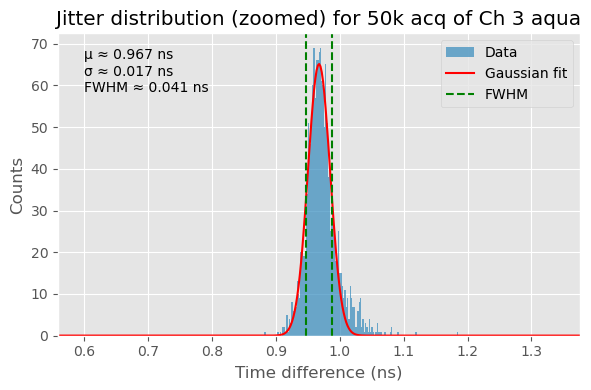

(np.float64(9.673705653375245e-10),
 np.float64(1.73606201294608e-11),
 np.float64(4.088113627502209e-11))

In [193]:
my_fcts.plot_jitter_gaussian_two_views(all_deltas, bins_fit=5000, bins=5000, save_full_fig=True, save_zoomed_fig=True, zoom_factor=20)